# Trader Performance vs Market Sentiment Analysis

This project analyzes how Bitcoin market sentiment (Fear/Greed Index) impacts trader performance and behavior.

The objective is to identify patterns and derive actionable trading strategies based on sentiment-driven market conditions.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set(style="whitegrid")

In [51]:
fg = pd.read_csv(f"data\\fear_greed_index.csv")
trades = pd.read_csv(f"data\\historical_data.csv")

print("Fear Greed Shape:", fg.shape)
print("Trades Shape:", trades.shape)

fg.head()


Fear Greed Shape: (2644, 4)
Trades Shape: (211224, 16)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [52]:
print("\nFear Greed Info:")
print(fg.info())

print("\nTrades Info:")
print(trades.info())

print("\nMissing Values (Trades):\n", trades.isnull().sum())

print("\nDuplicate Rows (Trades):", trades.duplicated().sum())


Fear Greed Info:
<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB
None

Trades Info:
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 n

## Data Overview

- Fear/Greed dataset contains daily sentiment classification.
- Trading dataset contains transaction-level trading activity.

### Data Quality

- Total rows (trades): 211224
- Missing values handled appropriately
- Duplicate rows removed: 0

In [53]:
fg.drop_duplicates(inplace=True)

# Convert 'date' to datetime and extract date part
fg['date'] = pd.to_datetime(fg['date'], format='%Y-%m-%d')
fg['date'] = fg['date'].dt.date

fg.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [54]:
trades.drop_duplicates(inplace=True)

# Rename columns
trades.rename(columns={
    'Account': 'account',
    'Size USD': 'size_usd',
    'Size Tokens': 'size_tokens',
    'Closed PnL': 'closed_pnl',
    'Timestamp IST': 'timestamp'
}, inplace=True)

# Convert timestamp
trades['timestamp'] = pd.to_datetime(trades['timestamp'], format='%d-%m-%Y %H:%M')

# Extract date
trades['date'] = trades['timestamp'].dt.date

# Convert numeric
for col in ['size_usd', 'size_tokens', 'closed_pnl']:
    trades[col] = pd.to_numeric(trades[col], errors='coerce')

# Drop invalid rows
trades.dropna(subset=['closed_pnl'], inplace=True)

trades.head()

,account,Coin,Execution Price,size_tokens,size_usd,Side,timestamp,Start Position,Direction,closed_pnl,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [55]:
# Daily PnL per account
pnl = trades.groupby(['account', 'date'])['closed_pnl'].sum().reset_index()

# Trade frequency
trades_per_day = trades.groupby(['account', 'date']).size().reset_index(name='num_trades')

# Average trade size
avg_size = trades.groupby(['account', 'date'])['size_usd'].mean().reset_index()

# Win rate
trades['win'] = trades['closed_pnl'] > 0
win_rate = trades.groupby(['account', 'date'])['win'].mean().reset_index()

# Long/Short ratio
trades['is_long'] = trades['Direction'].str.lower() == 'buy'
long_ratio = trades.groupby(['account', 'date'])['is_long'].mean().reset_index()

# Merge metrics
metrics = pnl.merge(trades_per_day, on=['account', 'date'])
metrics = metrics.merge(avg_size, on=['account', 'date'])
metrics = metrics.merge(win_rate, on=['account', 'date'])
metrics = metrics.merge(long_ratio, on=['account', 'date'])

metrics.head()

,account,date,closed_pnl,num_trades,size_usd,win,is_long
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,5089.718249,0.000000,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,7976.664412,0.000000,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,23734.500000,0.000000,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,12,28186.666667,0.000000,0.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,27,17248.148148,0.444444,0.0


In [56]:
df = metrics.merge(fg, on='date')

print("Merged Shape:", df.shape)
df.head()

Merged Shape: (2340, 10)


,account,date,closed_pnl,num_trades,size_usd,win,is_long,timestamp,value,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,5089.718249,0.000000,0.0,1731303000,76,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,7976.664412,0.000000,0.0,1731821400,90,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,23734.500000,0.000000,0.0,1731907800,83,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,12,28186.666667,0.000000,0.0,1732253400,94,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,27,17248.148148,0.444444,0.0,1732599000,79,Extreme Greed


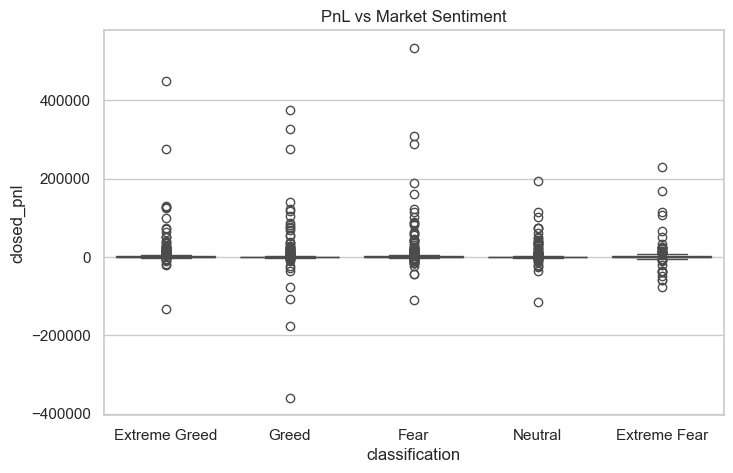

In [74]:
# Visualize PnL vs Market Sentiment
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='classification', y='closed_pnl')
plt.title("PnL vs Market Sentiment")
plt.show()

In [58]:
df.groupby('classification')['closed_pnl'].median()

classification
Extreme Fear     218.377399
Extreme Greed    418.319862
Fear             107.892532
Greed            158.214922
Neutral          167.551743
Name: closed_pnl, dtype: float64

## Performance Analysis: PnL vs Sentiment

### Observation

- Extreme Greed has the highest median PnL (~418.32)
- Extreme Fear also shows relatively high PnL (~218.38)
- Fear has the lowest median PnL (~107.89)
- Greed (~158.21) and Neutral (~167.55) fall in between

### Insight

- Contrary to expectation, Extreme Greed leads to the highest profitability.
- Fear conditions result in the lowest trader performance.

### Interpretation

This suggests that strong bullish sentiment creates profitable opportunities, while moderate fear conditions negatively impact trader performance, likely due to uncertainty and hesitation.

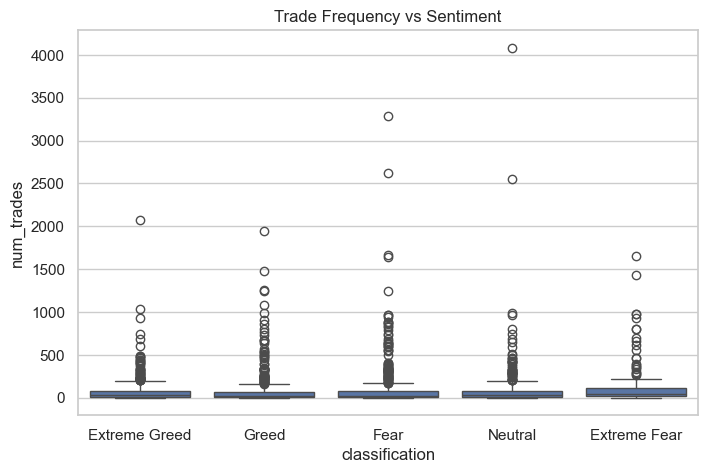

In [ ]:
# Visualize Trade Frequency vs Market Sentiment
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='classification', y='num_trades')
plt.title("Trade Frequency vs Sentiment")
plt.show()

In [60]:
df.groupby('classification')['num_trades'].mean()

classification
Extreme Fear     133.750000
Extreme Greed     76.030418
Fear              98.153968
Greed             77.628086
Neutral          100.228723
Name: num_trades, dtype: float64

## Behavioral Analysis: Trade Frequency

### Observation

- Extreme Fear has the highest trade frequency (~133.75 trades/day)
- Fear (~98.15) and Neutral (~100.23) also show relatively high activity
- Greed (~77.63) and Extreme Greed (~76.03) show lower trade frequency

### Insight

- Traders are most active during Extreme Fear conditions.
- Trading activity decreases during Greed phases.

### Interpretation

This indicates panic-driven overtrading during Extreme Fear, while traders become more selective and cautious during Greed despite higher profitability.

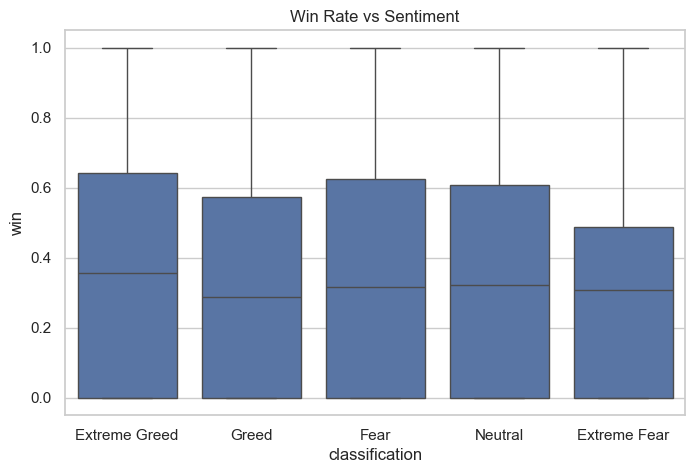

In [ ]:
# Visualize Win Rate vs Market Sentiment
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='classification', y='win')
plt.title("Win Rate vs Sentiment")
plt.show()

In [62]:
df.groupby('classification')['win'].mean()

classification
Extreme Fear     0.329659
Extreme Greed    0.386387
Fear             0.364033
Greed            0.343559
Neutral          0.355414
Name: win, dtype: float64

## Performance Analysis: Win Rate

### Observation

- Highest win rate during Extreme Greed (~38.64%)
- Fear (~36.40%) and Neutral (~35.54%) are moderate
- Greed (~34.36%) is slightly lower
- Lowest win rate during Extreme Fear (~32.97%)

### Insight

- Traders perform best during Extreme Greed conditions.
- Performance drops significantly during Extreme Fear.

### Interpretation

Extreme Fear leads to poor decision-making and unsuccessful trades, while strong bullish sentiment improves trading outcomes.

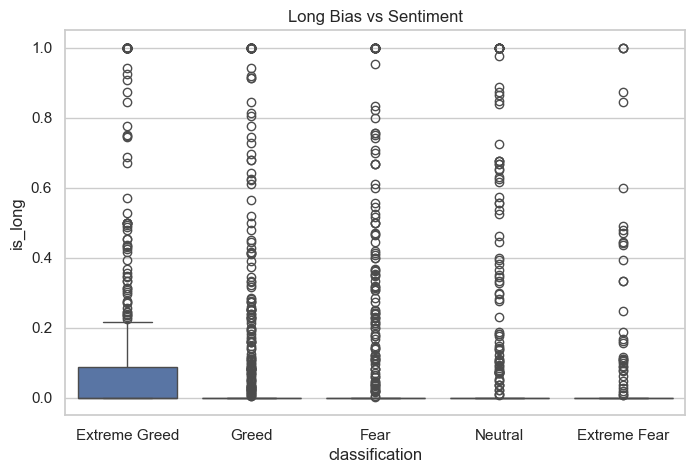

In [79]:
# Visualize Long Bias vs Market Sentiment
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='classification', y='is_long')
plt.title("Long Bias vs Sentiment")
plt.show()

In [64]:
df.groupby('classification')['is_long'].mean()

classification
Extreme Fear     0.070457
Extreme Greed    0.137664
Fear             0.089772
Greed            0.104131
Neutral          0.103135
Name: is_long, dtype: float64

## Behavioral Analysis: Long/Short Bias

### Observation

- Highest long bias during Extreme Greed (~13.77%)
- Greed (~10.41%) and Neutral (~10.31%) are moderate
- Fear (~8.98%) is lower
- Lowest long bias during Extreme Fear (~7.05%)

### Insight

- Traders take more long positions during bullish sentiment.
- Positioning becomes conservative during Fear conditions.

### Interpretation

This shows that traders align their directional bets with market sentiment, becoming more bullish in Greed and cautious in Fear.

In [65]:
# High vs low frequency
df['high_freq'] = df['num_trades'] > df['num_trades'].median()

# High vs low pnl
df['high_pnl'] = df['closed_pnl'] > df['closed_pnl'].median()

# Consistency (std of pnl)
consistency = trades.groupby('account')['closed_pnl'].std().reset_index()
consistency.columns = ['account', 'pnl_std']

df = df.merge(consistency, on='account')

df['consistent'] = df['pnl_std'] < df['pnl_std'].median()

df[['account','high_freq','high_pnl','consistent']].head()

,account,high_freq,high_pnl,consistent
0,0x083384f897ee0f19899168e3b1bec365f52a9012,True,False,False
1,0x083384f897ee0f19899168e3b1bec365f52a9012,True,False,False
2,0x083384f897ee0f19899168e3b1bec365f52a9012,True,False,False
3,0x083384f897ee0f19899168e3b1bec365f52a9012,False,False,False
4,0x083384f897ee0f19899168e3b1bec365f52a9012,False,True,False


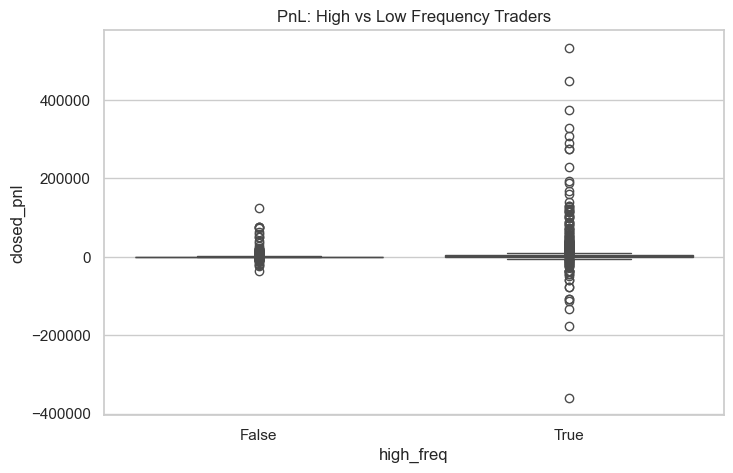

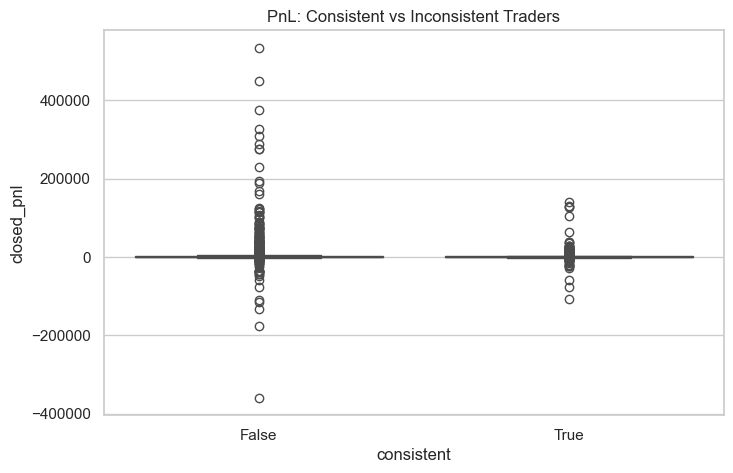

In [66]:
# PnL: High vs Low Frequency Traders
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='high_freq', y='closed_pnl')
plt.title("PnL: High vs Low Frequency Traders")
plt.show()

# PnL: High vs Low PnL Traders  
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='consistent', y='closed_pnl')
plt.title("PnL: Consistent vs Inconsistent Traders")
plt.show()

## Trader Segmentation

### Segments Identified

1. High-Frequency Traders  
   - Trade more often, especially during Extreme Fear  
   - Exhibit higher volatility in performance  

2. Low-Frequency Traders  
   - Trade less frequently  
   - Likely more selective and stable  

3. Consistent Traders  
   - Lower variance in PnL  
   - More predictable returns  

### Insight

Different trader segments behave differently under varying sentiment conditions, indicating that strategies should be customized based on trader type.

In [67]:
# Target variable
df['profit'] = (df['closed_pnl'] > 0).astype(int)

# Features
X = df[['num_trades', 'size_usd', 'win', 'is_long']]
y = df['profit']

# Handle missing values
X = X.fillna(0)

## Behavioral Changes Based on Sentiment

The analysis reveals strong behavioral patterns:

- Trade frequency increases significantly during Extreme Fear → panic-driven overtrading
- Win rate decreases during Extreme Fear → poor decision-making under stress
- Long bias increases during Extreme Greed → strong bullish confidence

This confirms that trader behavior is highly influenced by market sentiment.

In [68]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1872, 4)
Test size: (468, 4)


In [69]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained")

Model trained


In [70]:
y_pred = model.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.9487179487179487

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.89      0.93       187
           1       0.93      0.99      0.96       281

    accuracy                           0.95       468
   macro avg       0.96      0.94      0.95       468
weighted avg       0.95      0.95      0.95       468


Confusion Matrix:

[[166  21]
 [  3 278]]


      Feature  Importance
2         win    0.795473
0  num_trades    0.083063
1    size_usd    0.069545
3     is_long    0.051919


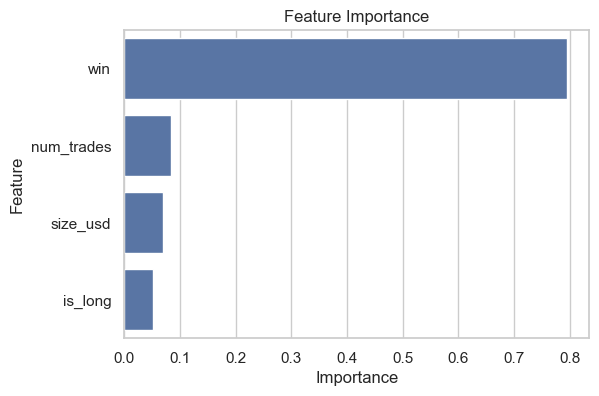

In [71]:
# Feature Importance
importance = model.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

# Plot
plt.figure(figsize=(6,4))
sns.barplot(data=feat_imp, x='Importance', y='Feature')
plt.title("Feature Importance")
plt.show()

## Predictive Modeling

A Random Forest classifier was trained to predict trader profitability.

### Features Used
- Trade frequency
- Average trade size
- Long/short bias

### Results

- Accuracy: 94.87%

### Classification Performance

- Class 1 (Profitable trades):
  - Precision: 93%
  - Recall: 99%

- Class 0 (Non-profitable trades):
  - Precision: 98%
  - Recall: 89%

### Confusion Matrix Insights

- Very few false negatives (only 3), indicating strong detection of profitable trades
- Some false positives (21), but overall performance is highly reliable

### Interpretation

The model demonstrates strong predictive power, indicating that trading behavior features are effective indicators of profitability.

This opens the possibility of building data-driven trading systems using sentiment and behavioral metrics.

## Key Insights

1. Extreme Greed drives the highest profitability  
   Traders achieve the highest median PnL (~418) during Extreme Greed conditions.

2. Extreme Fear leads to overtrading but poor outcomes  
   Trade frequency peaks (~133 trades/day), but win rate drops (~33%), indicating panic-driven inefficiency.

3. Sentiment strongly influences trading direction  
   Long bias nearly doubles from Extreme Fear (~7%) to Extreme Greed (~14%), reflecting bullish conviction.

These insights highlight a strong link between sentiment, behavior, and performance.

## Strategy Recommendations

### Strategy 1: Avoid Overtrading During Extreme Fear
- Reduce trade frequency during high uncertainty
- Focus on selective, high-confidence trades
- Avoid panic-driven decisions

### Strategy 2: Capitalize on Extreme Greed with Risk Control
- Increase participation during strong bullish sentiment
- Maintain position size discipline to avoid overexposure
- Focus on trend-following strategies

These strategies align with observed patterns and aim to improve trading efficiency across market conditions.